{
    'topic': '猫',
    'poem': '## 
月と縁側\n\n招き入れるのは、むせ返るような夏の匂い。\n鈴の音をぶら下げた首が、静かに低く唸る。\n\nお前の眼は琥珀色
の夜だ。\n縁側に落ちる影の形を、ゆっくりとなぞる。\n\n爪を研ぐ音が、板張りの時間を刻む。\n喉を鳴らす振動は、星の瞬
きより確かで。\n\n昼の熱をはらんだ畳の上、\nお前は液体の午後になる。\n\n鳥が逃げる速さで\n蝶が舞う刹那で\n影が伸び
る弧を描いて跳ぶ。\n\n呼んでも来ない。呼んでも。\nだけど、月が満ちる夜には\n勝手に膝の上で丸くなる。\n\nその体温は
、あの日のまま。\nあの夏の、青い匂いのする記憶のまま。\n\n風が立てば、魂の鬣が揺れる。\n闇と光の境に\nお前はいつも
、ただ、在る。\n\nやがて朝が来て、光が差せば\nお前はまた、見えなくなる。\n何かの気配だけを残して。\n\n季節が何度巡
っても、\n縁側には、まだあたたかい\nお前の形の痕が残っている。',
    'content_type': '詩'
}

**************************************************

{
    'topic': '猫',
    'joke': '猫をテーマにしたジョークですね。いくつかご用意しました。\n\n**1. 
定番のドアのジョーク**\n\n猫がドアをノックしました。\n「コンコン」\n「誰かと思ったら、ネコか。どうしたんだい？」\n
「すみません、トイレを貸していただけませんか？」\n「ああ、いいぞ。入って入って。…ところで、トイレはどこで覚えたんだ
い？」\n「さっき、あなたが犬の散歩をしているのを見て、ここなら大丈夫だと思ったんです。」\n\n**2. 
キャットフードのジョーク**\n\nスーパーで、妻が夫に言いました。\n「ねえ、キャットフードを買ってきてくれる？」\n夫は
気乗りしない様子で答えました。\n「やだよ、高いし、まずそうだし。」\n妻はため息をついて言いました。\n「違うのよ、猫
のエサよ。」\n夫は安心した顔で言いました。\n「ああ、それならいいんだ。猫のエサか。…って、うちに猫なんていたっけ？」
\n妻はニッコリ笑って言いました。\n「いないわよ。でも、あなたがそんなに嫌がるなら、今夜の夕食はキャットフードにしよ
うかと思ってね。」\n\n**3. 
インターネット猫のジョーク**\n\nある猫がインターネットカフェに入っていきました。\n店員が言いました。\n「すみません
、うちのパソコンはマウスが壊れているんですよ。」\nすると猫はしっぽを振りながら言いました。\n「大丈夫だよ。俺、キー
ボードでタイプするから。」\n\n**4. 
哲学的な猫のジョーク**\n\n猫が2匹、日向ぼっこをしていました。\n子猫が言いました。\n「お母さん、人間って、どうして自
分たちのことを“主人”って呼ぶの？」\n母猫は目を細めて言いました。\n「さあね。きっとあれが精一杯の自尊心なんでしょう
。私たち猫がここで昼寝をしている間も、あの人たちはせっせと働いて、私たちに美味しいものを作ってくれるんだから。」\n\
n**5. 
早口言葉風のジョーク**\n\n「猫が子猫をこねこねこねて、子猫が猫をこねこねこねた。こねた子猫はねこねこして、こねた猫
もねこねこした。さあ、どっちが本物の猫で、どっちがこねこねされた子猫だ？ 
…答えは、みんな猫だ。」\n\nいかがでしたか？どのジョークも、猫のツンデレな性格や、人間を見下すような独特の視点をテー
マにしています。',
    'content_type': 'ジョーク'
}

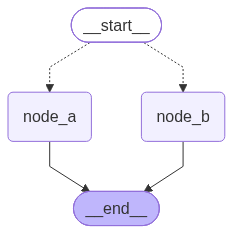

In [3]:
from typing import TypedDict,Literal
from langchain_deepseek import ChatDeepSeek
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
load_dotenv(override=True)
from rich import print

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking":{
            "type":"disabled"
        }
    }
)

#1. 状態を定義
class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str
    content_type: str

#2. ノードを定義
def node_a(state: OverAllState) -> OverAllState:
    poem = model.invoke([f"{state['topic']}をテーマにした詩を書いてください"]).content
    return {
        "poem": poem
    }

def node_b(state: OverAllState) -> OverAllState:
    joke = model.invoke([f"{state['topic']}をテーマにしたジョークを書いてください"]).content
    return {
        "joke": joke
    }

def my_route(state: OverAllState) -> Literal["node_a","node_b"]:
    if "詩" in state["content_type"]:
        return "node_a"
    else:
        return "node_b"


#3. グラフを構築
builder = StateGraph(state_schema=OverAllState)
builder.add_node(node_a)
builder.add_node(node_b)

builder.add_conditional_edges(START,my_route)
builder.add_edge("node_b",END)
builder.add_edge("node_a",END)

graph = builder.compile()
poem_res = graph.invoke({"topic": "猫","content_type":"詩"})
print(poem_res)
print("*"*50)
joke_res = graph.invoke({"topic": "猫","content_type":"ジョーク"})
print(joke_res)

from IPython.display import display
display(graph)
